In [205]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import adjusted_rand_score

df = pd.read_csv("sample_citibike_2023.csv")

/tmp/ipykernel_496/4079058575.py:12: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("sample_citibike_2023.csv")


In [206]:
df.head()

,Unnamed: 0,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,12536574,6A1558E5EB8E9B3B,classic_bike,2023-06-25 06:44:47,2023-06-25 07:02:43,Walton Ave & E 168 St,8179.03,Icahn Stadium,7514.01,40.836655,-73.918324,40.793460,-73.923890,member
1,20766033,F5DAABF8EAD39B32,classic_bike,2023-08-15 18:05:37,2023-08-15 18:12:06,Grand Army Plaza & Central Park S,6839.10,2 Ave & E 72 St,6925.09,40.764004,-73.973974,40.768762,-73.958408,member
2,17246346,CC4D3C1C193EBCDD,classic_bike,2023-07-05 15:00:28,2023-07-05 15:06:34,Knickerbocker Ave & Thames St,5018.06,Melrose St & Broadway,4801.04,40.705446,-73.929975,40.697481,-73.935877,casual
3,3860641,541D7A53817AF238,classic_bike,2023-03-05 11:29:02,2023-03-05 11:36:36,DeKalb Ave & Vanderbilt Ave,4461.04,Pacific St & Classon Ave,4148.07,40.689425,-73.968898,40.679194,-73.958790,member
4,27285265,EACA2B802BFED979,classic_bike,2023-10-17 15:02:23,2023-10-17 15:06:40,Liberty St & Broadway,5105.01,West Thames St,5114.06,40.708164,-74.010369,40.708347,-74.017134,member


In [207]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 14 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   Unnamed: 0          1000000 non-null  int64  
 1   ride_id             1000000 non-null  object 
 2   rideable_type       1000000 non-null  object 
 3   started_at          1000000 non-null  object 
 4   ended_at            1000000 non-null  object 
 5   start_station_name  999459 non-null   object 
 6   start_station_id    999459 non-null   object 
 7   end_station_name    997192 non-null   object 
 8   end_station_id      997192 non-null   object 
 9   start_lat           1000000 non-null  float64
 10  start_lng           1000000 non-null  float64
 11  end_lat             999287 non-null   float64
 12  end_lng             999287 non-null   float64
 13  member_casual       1000000 non-null  object 
dtypes: float64(4), int64(1), object(9)
memory usage: 106.8+ MB


In [208]:
df.duplicated().sum()

np.int64(0)

In [209]:
df.isna().sum()

,0
Unnamed: 0,0
ride_id,0
rideable_type,0
started_at,0
ended_at,0
start_station_name,541
start_station_id,541
end_station_name,2808
end_station_id,2808
start_lat,0


In [210]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

Feature engineering and selection

In [211]:
for col in cat_cols:
    print(col)
    print(df[col].unique())
    print('-' * 40)

ride_id
['6A1558E5EB8E9B3B' 'F5DAABF8EAD39B32' 'CC4D3C1C193EBCDD' ...
 '2892D1DA3F9483A1' '5FE9361CFBB85827' 'FFA3FFC5C92389D7']
----------------------------------------
rideable_type
['classic_bike' 'electric_bike' 'docked_bike']
----------------------------------------
started_at
['2023-06-25 06:44:47' '2023-08-15 18:05:37' '2023-07-05 15:00:28' ...
 '2023-02-04 15:04:44' '2023-08-16 18:06:38' '2023-05-18 20:36:48']
----------------------------------------
ended_at
['2023-06-25 07:02:43' '2023-08-15 18:12:06' '2023-07-05 15:06:34' ...
 '2023-02-04 15:07:40' '2023-08-16 18:22:09' '2023-05-18 20:40:43']
----------------------------------------
start_station_name
['Walton Ave & E 168 St' 'Grand Army Plaza & Central Park S'
 'Knickerbocker Ave & Thames St' ...
 'Hoboken Terminal - Hudson St & Hudson Pl' 'Corona Ave & 92 St'
 'Broadway & Van Cortlandt Park S']
----------------------------------------
start_station_id
['8179.03' '6839.10' '5018.06' ... 8547.04 4064.03 8535.01]
------------

In [212]:
df = df.drop(columns=['Unnamed: 0','ride_id','start_station_id','end_station_id'],axis=1)

In [213]:
df['started_at'] = pd.to_datetime(df['started_at'],format='mixed')
df['ended_at'] = pd.to_datetime(df['ended_at'],format='mixed')

In [214]:
df['ride_duration'] = (df['ended_at'] - df['started_at']).dt.total_seconds() / 60
df['start_hour'] = df['started_at'].dt.hour
df['start_day'] = df['started_at'].dt.dayofweek
df['month'] = df['started_at'].dt.month

In [215]:
df['member_casual'] = df['member_casual'].map({
    'member': 1,
    'casual': 0
})

In [216]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

In [217]:
# numeric
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# categorical
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

* Noticed that ride_duration has negatine min value and max 11 days which is
impossible. Heavily skewed wil log transform it.
* member column has heavy imbalance. 81% are members and 19% are casual
*   Peak starting hours
* Latitude and Longitude are consistent; it refers to New York city


In [218]:
df[num_cols].describe()

,start_lat,start_lng,end_lat,end_lng,member_casual,ride_duration,start_hour,start_day,month
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,40.740204,-73.972587,40.740071,-73.972662,0.814572,14.849927,14.068359,2.918891,6.936009
std,0.040891,0.028043,0.040866,0.028053,0.388645,60.943801,5.053448,1.935825,3.085697
min,40.597389,-74.026852,40.610000,-74.080000,0.000000,-53.933333,0.000000,0.000000,1.000000
25%,40.715030,-73.992530,40.715030,-73.992663,1.000000,5.000000,10.000000,1.000000,5.000000
50%,40.739126,-73.980166,40.739017,-73.980144,1.000000,9.033333,15.000000,3.000000,7.000000
75%,40.763278,-73.955857,40.763154,-73.955931,1.000000,16.183333,18.000000,5.000000,9.000000
max,40.890000,-73.814664,40.920000,-73.800000,1.000000,16896.933333,23.000000,6.000000,12.000000


*   Classic bike - mostly used bike
*   W 21 St and 6 Ave is a central hub for commuters
* High cardinality for station names

In [219]:
df[cat_cols].describe()

,rideable_type,start_station_name,end_station_name
count,1000000,1000000,1000000
unique,3,2221,2244
top,classic_bike,W 21 St & 6 Ave,W 21 St & 6 Ave
freq,897184,4586,6805


* Latitude and longitude outliers are possible because they might be distant locations
* Member_casual is imbalanced, hence, treats 0 as outliers which is not the case (binary column)
* Ride duration seems to have outliers

In [220]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"\nColumn: {col}")
    print(f"IQR: {IQR}")
    print(f"Outliers: {outliers.shape[0]}")


Column: start_lat
IQR: 0.0482483947499972
Outliers: 23990

Column: start_lng
IQR: 0.03667278274998864
Outliers: 16102

Column: end_lat
IQR: 0.04812400000000139
Outliers: 24507

Column: end_lng
IQR: 0.03673207999999306
Outliers: 16313

Column: member_casual
IQR: 0.0
Outliers: 185428

Column: ride_duration
IQR: 11.183333333333334
Outliers: 65295

Column: start_hour
IQR: 8.0
Outliers: 0

Column: start_day
IQR: 4.0
Outliers: 0

Column: month
IQR: 4.0
Outliers: 0


<Axes: xlabel='start_lng', ylabel='start_lat'>

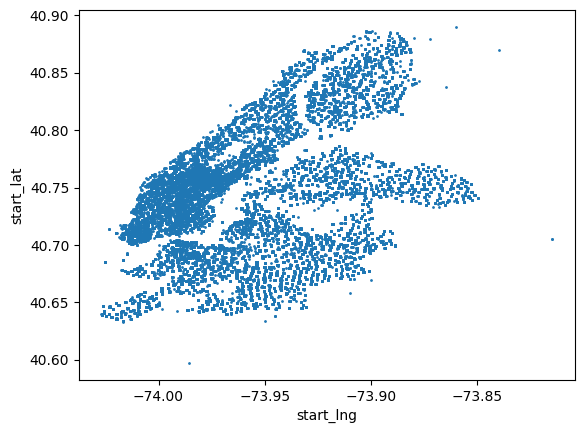

In [221]:
df.plot.scatter(x="start_lng", y="start_lat", s=1)

<Axes: xlabel='end_lng', ylabel='end_lat'>

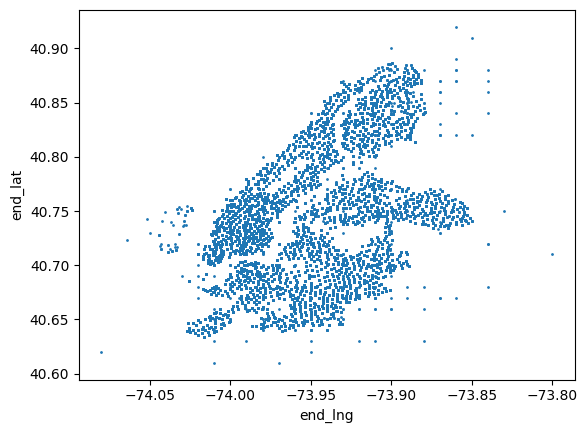

In [222]:
df.plot.scatter(x="end_lng", y="end_lat", s=1)

Most bike rides are very short but very few stretch it to 17500 minutes

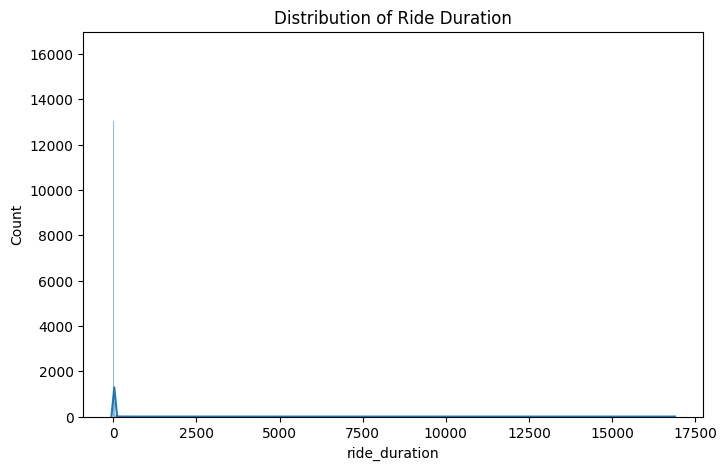

In [223]:
plt.figure(figsize=(8,5))
sns.histplot(df['ride_duration'], kde=True)
plt.title("Distribution of Ride Duration")
plt.show()

In [224]:
print("Skew:", df['ride_duration'].skew())

Skew: 81.54315008378161


In [225]:
df[df['ride_duration'] <= 0]

,rideable_type,started_at,ended_at,start_station_name,end_station_name,start_lat,start_lng,end_lat,end_lng,member_casual,ride_duration,start_hour,start_day,month
3240,electric_bike,2023-08-12 09:57:36,2023-08-12 09:57:36,Prospect Park W & 20 St,Prospect Park W & 20 St,40.656633,-73.983864,40.656633,-73.983864,1,0.000000,9,5,8
3495,classic_bike,2023-02-08 19:16:10,2023-02-08 19:16:10,W 18 St & 6 Ave,W 18 St & 6 Ave,40.739713,-73.994564,40.739713,-73.994564,1,0.000000,19,2,2
5267,classic_bike,2023-07-02 22:12:20,2023-07-02 22:12:20,Lafayette Ave & St James Pl,Lafayette Ave & St James Pl,40.688515,-73.964763,40.688515,-73.964763,1,0.000000,22,6,7
5646,classic_bike,2023-07-06 11:54:40,2023-07-06 11:54:40,Roebling St & N 4 St,Roebling St & N 4 St,40.714690,-73.957390,40.714690,-73.957390,1,0.000000,11,3,7
5714,classic_bike,2023-12-27 20:38:58,2023-12-27 20:38:58,43 St & Broadway,43 St & Broadway,40.757696,-73.916681,40.757728,-73.916637,1,0.000000,20,2,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
987780,classic_bike,2023-04-24 15:35:57,2023-04-24 15:35:57,E 118 St & 3 Ave,E 118 St & 3 Ave,40.799171,-73.938846,40.799139,-73.938915,1,0.000000,15,0,4
988073,classic_bike,2023-05-27 17:12:10,2023-05-27 17:12:10,Wilkins Ave & Crotona Park E,Wilkins Ave & Crotona Park E,40.835247,-73.895095,40.835302,-73.895133,0,0.000000,17,5,5
993572,classic_bike,2023-09-08 08:45:24,2023-09-08 08:45:24,W 45 St & 8 Ave,W 45 St & 8 Ave,40.759291,-73.988597,40.759291,-73.988597,1,0.000000,8,4,9
997850,classic_bike,2023-10-17 12:21:14,2023-10-17 12:21:13,E 89 St & 3 Ave,E 89 St & 3 Ave,40.780736,-73.952507,40.780628,-73.952167,1,-0.016667,12,1,10


In [226]:
df = df[(df['ride_duration'] > 0) & (df['ride_duration'] < 360)]
df['ride_duration'] = np.log1p(df['ride_duration'])
print("New Skew:", df['ride_duration'].skew())

New Skew: -0.03044864751641148


/tmp/ipykernel_496/3103104256.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ride_duration'] = np.log1p(df['ride_duration'])


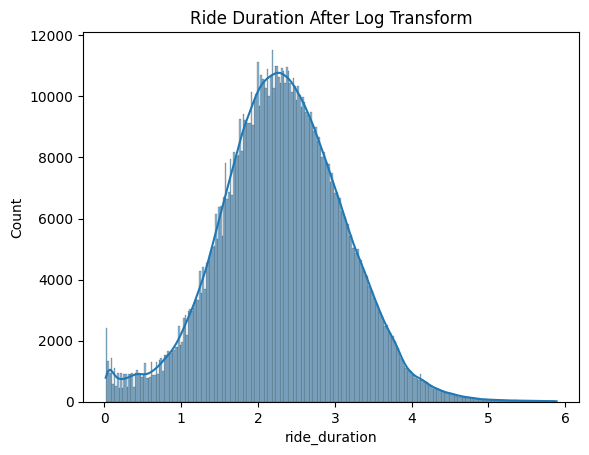

In [227]:
sns.histplot(df['ride_duration'], kde=True)
plt.title("Ride Duration After Log Transform")
plt.show()

* Heavily imbalanced
* may not be very informative for behaviourial clustering

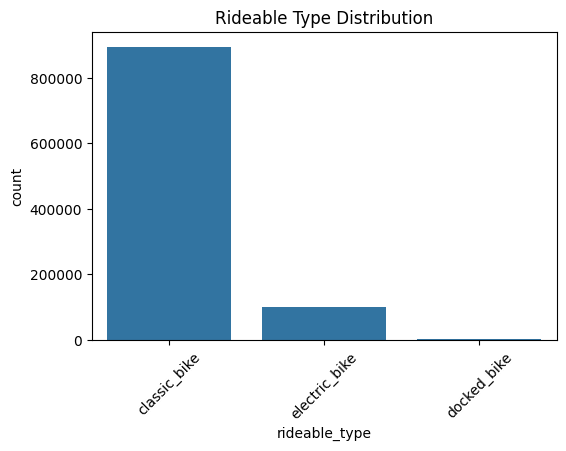

In [228]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='rideable_type')
plt.title("Rideable Type Distribution")
plt.xticks(rotation=45)
plt.show()

Members are ususally commuters and casual riders are ususally tourists or ride for leisure

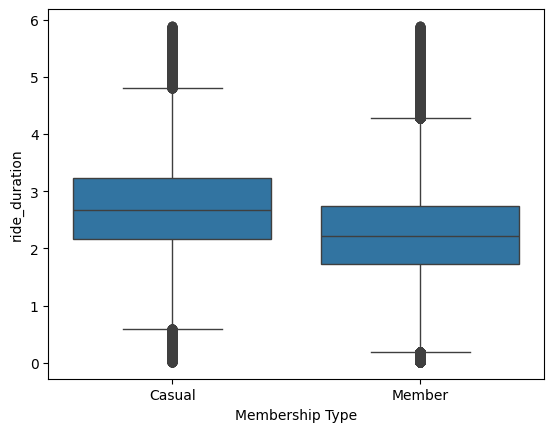

In [229]:
sns.boxplot(
    data=df,
    x='member_casual',
    y='ride_duration'
)

plt.xticks([0,1], ['Casual', 'Member'])
plt.xlabel("Membership Type")
plt.show()

Members go for shorter rides, casual riders go for longer riders

In [230]:
pd.crosstab(
    pd.cut(np.expm1(df['ride_duration']),
           bins=[0,5,10,20,40,80,200]),
    df['member_casual']
)

member_casual,0,1
ride_duration,,
"(0, 5]",21665,228786
"(5, 10]",44312,251203
"(10, 20]",58720,216291
"(20, 40]",41333,96813
"(40, 80]",14513,18177
"(80, 200]",3727,1856


Peak Ride time

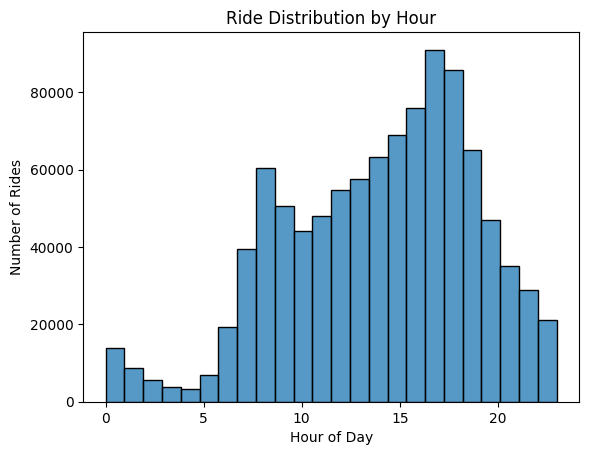

In [240]:
sns.histplot(df['start_hour'], bins=24)

plt.xlabel("Hour of Day")
plt.ylabel("Number of Rides")
plt.title("Ride Distribution by Hour")
plt.show()

Ride timing behavioours across riders

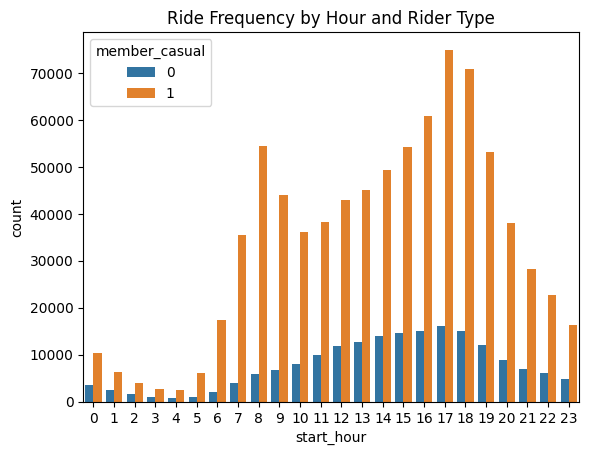

In [241]:
sns.countplot(data=df, x='start_hour', hue='member_casual')

plt.title("Ride Frequency by Hour and Rider Type")
plt.show()

In [231]:
num_features = [
    'ride_duration',
    'start_day',
    'month'
]

cat_features = ['member_casual']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first'), cat_features)
    ]
)

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('kmeans', KMeans(random_state=42))
])


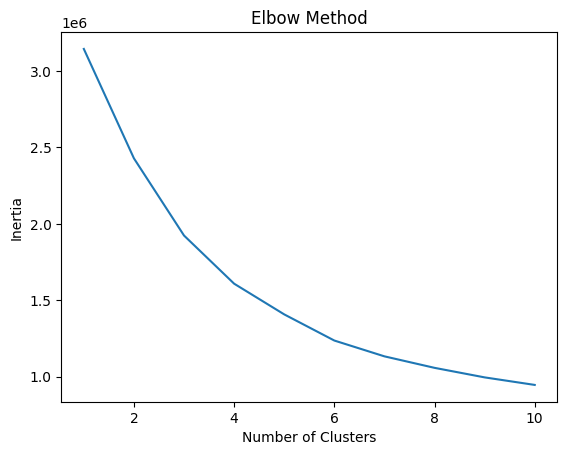

In [232]:
inertia = []

for k in range(1, 11):
    pipeline.set_params(kmeans__n_clusters=k)
    pipeline.fit(df)
    inertia.append(pipeline.named_steps['kmeans'].inertia_)

plt.plot(range(1, 11), inertia)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [233]:
df_sample = df.sample(n=30000, random_state=42)

for k in range(2,5):
    pipeline.set_params(kmeans__n_clusters=k)
    pipeline.fit(df_sample)

    X_processed = pipeline.named_steps['preprocessing'].transform(df_sample)
    labels = pipeline.named_steps['kmeans'].labels_

    score = silhouette_score(X_processed, labels)
    print(k, score)

2 0.23168181377451438
3 0.232924973617926
4 0.23742207364523243


In [234]:

kmeans1 = KMeans(n_clusters=4, random_state=42, n_init=20)
labels1 = kmeans1.fit_predict(X_processed)

kmeans2 = KMeans(n_clusters=4, random_state=99, n_init=20)
labels2 = kmeans2.fit_predict(X_processed)

ari = adjusted_rand_score(labels1, labels2)
print("Adjusted Rand Index:", ari)

Adjusted Rand Index: 0.9679066700819926


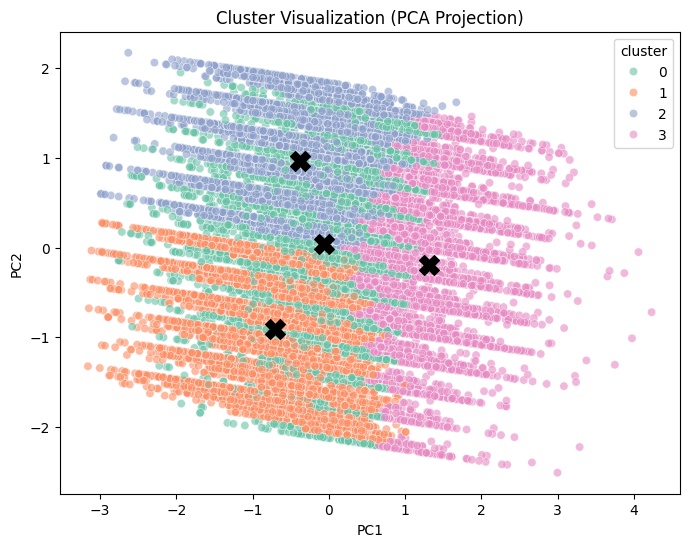

In [235]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Reducing dimensions
pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_processed)

kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_processed)

viz_df = pd.DataFrame({'PC1': X_pca[:, 0],'PC2': X_pca[:, 1],'cluster': clusters})

viz_sample = viz_df.sample(20000, random_state=42)

plt.figure(figsize=(8,6))

sns.scatterplot(data=viz_sample,x='PC1',y='PC2',hue='cluster',palette='Set2',alpha=0.6)

centroids = pca.transform(kmeans.cluster_centers_)

plt.scatter(centroids[:,0],centroids[:,1],s=200,c='black',marker='X',label='centroids')

plt.title("Cluster Visualization (PCA Projection)")
plt.show()

In [243]:
print(pca.explained_variance_ratio_)

print("Variance captured by first 2 PCs:",
      pca.explained_variance_ratio_[:2].sum())

[0.33871008 0.31666848 0.30015706 0.04446438]
Variance captured by first 2 PCs: 0.6553785598070528


In [237]:
df_sample['cluster'] = clusters
df_sample.groupby('cluster').agg({
    'ride_duration':'mean',
    'start_day':'mean',
    'month':'mean',
    'member_casual':'mean'
})

,ride_duration,start_day,month,member_casual
cluster,,,,
0,1.570558,4.543413,7.371420,0.883178
1,2.230129,1.716239,3.583621,0.874792
2,2.276717,1.381249,9.459399,0.848862
3,3.122498,4.579165,7.167450,0.650848


Cluster 0: Very Short Member Trips

* Average ride duration: ~4 minutes
* Average day: around Friday–Saturday
* Average month: July (summer)
* Member proportion: ~88% members

Cluster 1: Short Weekday Commuter Rides

* Average ride duration: ~8 minutes
* Average day: Monday–Tuesday
* Average month: early spring
* Member proportion: ~87% members

Cluster 2 — Moderate Weekday Rides (Seasonal)

* Average ride duration: ~9 minutes
* Average day: early weekday (Monday–Tuesday)
* Average month: September (fall)
* Member proportion: ~85% members

Cluster 3 — Longer Casual Leisure Rides

* Average ride duration: ~22 minutes
* Average day: Friday–Saturday
* Average month: summer
* Member proportion: ~65% members (higher casual usage)

In [238]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

agg = AgglomerativeClustering(n_clusters=4)

labels_agg = agg.fit_predict(X_processed)

score = silhouette_score(X_processed, labels_agg)

print("Agglomerative Silhouette:", score)

Agglomerative Silhouette: 0.16749404281863173


In [239]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.5, min_samples=10)

labels_db = db.fit_predict(X_processed)

score = silhouette_score(X_processed, labels_db)

print("DBSCAN Silhouette:", score)

DBSCAN Silhouette: 0.026715867730450545
